### Learning Objectives
1. Choose the correct cross-validation strategy for a given data scenario
2. Explain why nested cross-validation gives on unbiased performance estimate
3. SEt up on Optuna study with a custom objective function and TPE sampler
4. Interpret Optuna visualization plots
5. Implement early stopping in gradient boosting models
6. Compare GridSearchCV, RandomizedSearchCV, and Optuna

In [1]:
!pip install optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    KFold, StratifiedKFold, RepeatedKFold,
    GroupKFold, TimeSeriesSplit, cross_val_score,
    GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import loguniform, uniform
from collections import Counter
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
import time
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All imports successful.")

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 11.2 MB/s  0:00:00

   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- --

c:\Users\HARSH\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
np.random.seed(42)
n = 200

sqft = np.random.uniform(800, 3500, n)
bedrooms = np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.2, 0.4, 0.25, 0.1])
age = np.random.uniform(0, 50, n)
distance_to_city = np.random.uniform(1, 30, n)

neighborhood = np.random.choice(['Downtown', 'Suburb_A', 'Suburb_B', 'Rural', 'Waterfront'], n,
                                 p=[0.25, 0.25, 0.2, 0.15, 0.15])

sale_month = np.sort(np.random.choice(range(1, 37), n))

listing_day = np.random.randint(1, 365, n)
agent_rating = np.random.uniform(1, 5, n)

neighborhood_multiplier = pd.Series(neighborhood).map({
    'Downtown': 1.4, 'Suburb_A': 1.0, 'Suburb_B': 0.95,
    'Rural': 0.7, 'Waterfront': 1.6
}).values

price = (
    (150 * sqft + 25000 * bedrooms - 1500 * age - 3000 * distance_to_city)
    * neighborhood_multiplier
    + 500 * sale_month
    + np.random.normal(0, 30000, n)
)

df = pd.DataFrame({
    'sqft': sqft, 'bedrooms': bedrooms, 'age': age,
    'distance_to_city': distance_to_city, 'neighborhood': neighborhood,
    'sale_month': sale_month, 'listing_day': listing_day,
    'agent_rating': agent_rating, 'price': price
})

df_encoded = pd.get_dummies(df.drop('price', axis=1), columns=['neighborhood'], drop_first=True)
X = df_encoded.values
y = df['price'].values
groups = df['neighborhood'].values

print("=" * 60)
print("   EXTENDED REAL ESTATE DATASET")
print("=" * 60)
print(f"   Rows: {len(df)}  |  Features: {df_encoded.shape[1]}")
print(f"   Price range: ${df['price'].min():,.0f} — ${df['price'].max():,.0f}")
print(f"   Neighborhoods: {df['neighborhood'].nunique()} groups")
print(f"   Time span: {df['sale_month'].min()} to {df['sale_month'].max()} months")
print("=" * 60)

   EXTENDED REAL ESTATE DATASET
   Rows: 200  |  Features: 11
   Price range: $-11,975 — $851,236
   Neighborhoods: 5 groups
   Time span: 1 to 36 months


In [3]:
df

,sqft,bedrooms,age,distance_to_city,neighborhood,sale_month,listing_day,agent_rating,price
0,1811.258321,3,5.156193,5.899117,Rural,1,233,3.634831,230776.799773
1,3366.928627,2,45.127645,9.079120,Downtown,1,224,2.992783,686414.721829
2,2776.383643,2,25.262619,6.133304,Suburb_B,2,319,3.221454,418205.019230
3,2416.377907,4,41.322873,3.572373,Suburb_B,2,60,3.876807,324152.474811
4,1221.250329,3,16.002480,4.498440,Suburb_A,2,335,1.913819,191999.664419
...,...,...,...,...,...,...,...,...,...
195,1742.865851,5,23.698082,26.291593,Downtown,35,356,1.405683,392031.454154
196,2760.080333,4,33.377887,28.031430,Waterfront,35,173,2.943487,605189.304204
197,3222.197702,3,8.615994,17.388862,Downtown,35,221,2.027106,739231.849778
198,3195.133346,4,9.614451,21.202874,Waterfront,36,119,2.139492,801815.059791


In [4]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

kfold_scores = cross_val_score(pipe, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='r2')

repeated_scores = cross_val_score(pipe, X, y,
                                   cv=RepeatedKFold(n_splits=5, n_repeats=10, random_state=42),
                                   scoring='r2')

gkf = GroupKFold(n_splits=5)
group_scores = cross_val_score(pipe, X, y, cv=gkf, groups=groups, scoring='r2')

tscv = TimeSeriesSplit(n_splits=5)
time_scores = cross_val_score(pipe, X, y, cv=tscv, scoring='r2')

print("=" * 60)
print("   CV STRATEGY COMPARISON (Same Model, Same Data)")
print("=" * 60)
print(f"   {'Strategy':<25s} {'Mean R²':>10s} {'Std':>8s} {'Min':>8s} {'Max':>8s}")
print("-" * 60)
for name, scores in [('KFold (5)', kfold_scores),
                      ('RepeatedKFold (5x10)', repeated_scores),
                      ('GroupKFold (5)', group_scores),
                      ('TimeSeriesSplit (5)', time_scores)]:
    print(f"   {name:<25s} {scores.mean():>10.4f} {scores.std():>8.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")
print("=" * 60)
print("\n   KEY INSIGHT: Same model, same data — different CV strategies")
print("   give DIFFERENT performance estimates!")
print("   GroupKFold and TimeSeriesSplit are often LOWER and MORE HONEST.")

   CV STRATEGY COMPARISON (Same Model, Same Data)
   Strategy                     Mean R²      Std      Min      Max
------------------------------------------------------------
   KFold (5)                     0.9030   0.0267   0.8656   0.9357
   RepeatedKFold (5x10)          0.9055   0.0246   0.8260   0.9524
   GroupKFold (5)               -1.0715   2.6486  -6.2771   0.8289
   TimeSeriesSplit (5)           0.8951   0.0200   0.8645   0.9195

   KEY INSIGHT: Same model, same data — different CV strategies
   give DIFFERENT performance estimates!
   GroupKFold and TimeSeriesSplit are often LOWER and MORE HONEST.


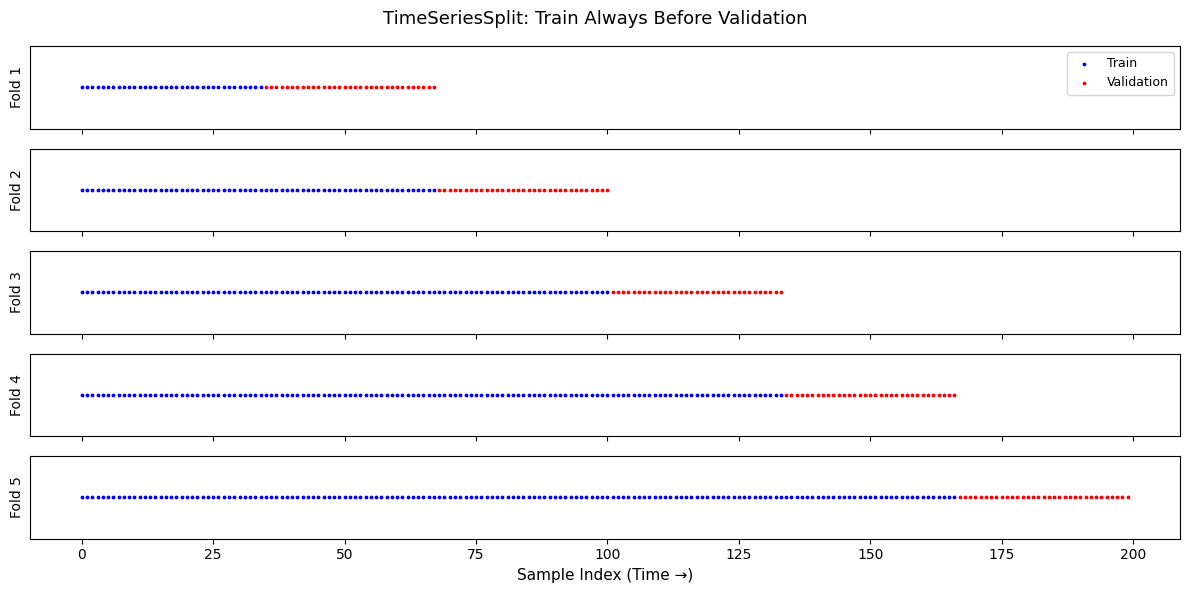

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(12, 6), sharex=True)
tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, val_idx) in enumerate(tscv.split(X)):
    axes[i].scatter(train_idx, [1]*len(train_idx), c='blue', s=3, label='Train')
    axes[i].scatter(val_idx, [1]*len(val_idx), c='red', s=3, label='Validation')
    axes[i].set_ylabel(f'Fold {i+1}', fontsize=10)
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Sample Index (Time \u2192)', fontsize=11)
fig.suptitle('TimeSeriesSplit: Train Always Before Validation', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Exercise 1: Starter code

# Simulate hospital dataset
np.random.seed(99)
n_patients = 150
draws_per_patient = np.random.choice([2, 3, 4, 5], n_patients)
patient_ids = np.repeat(np.arange(n_patients), draws_per_patient)
n_total = len(patient_ids)

# Features: blood glucose, cholesterol, blood pressure
X_hosp = np.column_stack([
    np.random.normal(100, 20, n_total),
    np.random.normal(200, 40, n_total),
    np.random.normal(120, 15, n_total)
])

# Labels: 80% negative, 20% positive (assigned at patient level)
patient_labels = np.random.choice([0, 1], n_patients, p=[0.8, 0.2])
y_hosp = patient_labels[patient_ids]

print(f"Total samples: {n_total}")
print(f"Unique patients: {n_patients}")
print(f"Class distribution: {dict(zip(*np.unique(y_hosp, return_counts=True)))}")

# TODO: Choose the correct CV strategy and run cross_val_score
# Hint: The data has BOTH grouped observations (same patient) AND class imbalance
# Consider: GroupKFold handles groups; StratifiedGroupKFold handles both

# cv_strategy = ???
# scores = cross_val_score(???, X_hosp, y_hosp, cv=cv_strategy, groups=patient_ids, scoring='accuracy')
# print(f"Mean accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

Total samples: 529
Unique patients: 150
Class distribution: {np.int64(0): np.int64(431), np.int64(1): np.int64(98)}


In [7]:
from sklearn.linear_model import LogisticRegression


cv_strategy = GroupKFold(n_splits=5)
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

scores = cross_val_score(clf, X_hosp, y_hosp, cv=cv_strategy,
                          groups=patient_ids, scoring='accuracy')

print("=" * 60)
print("   EXERCISE 1: SOLUTION")
print("=" * 60)
print(f"   Strategy: GroupKFold (n_splits=5)")
print(f"   Mean accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"   Fold scores: {[f'{s:.4f}' for s in scores]}")
print("-" * 60)
print("   Why GroupKFold: Each patient's multiple blood draws are kept")
print("   together in one fold, preventing data leakage from repeated")
print("   measurements of the same individual.")
print("=" * 60)

   EXERCISE 1: SOLUTION
   Strategy: GroupKFold (n_splits=5)
   Mean accuracy: 0.8147 +/- 0.1108
   Fold scores: ['0.6604', '0.8962', '0.7358', '0.9717', '0.8095']
------------------------------------------------------------
   Why GroupKFold: Each patient's multiple blood draws are kept
   together in one fold, preventing data leakage from repeated
   measurements of the same individual.


In [8]:
#Nested CV vs Non-Nested CV Comparisons
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

param_grid = {'model__alpha': np.logspace(-4, 4, 20)}

# Non-nested CV: find best hyperparameters and report best CV score
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X, y)
non_nested_score = grid.best_score_

In [9]:
non_nested_score

np.float64(0.9085559583654955)

In [10]:
#Nested CV: outer loop evaluates the entire tuning process
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
nested_scores = cross_val_score(grid, X, y, cv=outer_cv, scoring='r2')

print("=" * 60)
print("   NESTED vs NON-NESTED CROSS-VALIDATION")
print("=" * 60)
print(f"   Non-nested CV score (biased):   {non_nested_score:.4f}")
print(f"   Nested CV score (unbiased):     {nested_scores.mean():.4f} +/- {nested_scores.std():.4f}")
print(f"   Optimistic bias:                {non_nested_score - nested_scores.mean():.4f}")
print("-" * 60)
print("   The non-nested score is HIGHER because it used the same")
print("   data for both model selection AND evaluation.")
print("   The nested score is the HONEST estimate of real-world performance.")
print("=" * 60)

   NESTED vs NON-NESTED CROSS-VALIDATION
   Non-nested CV score (biased):   0.9086
   Nested CV score (unbiased):     0.9034 +/- 0.0260
   Optimistic bias:                0.0052
------------------------------------------------------------
   The non-nested score is HIGHER because it used the same
   data for both model selection AND evaluation.
   The nested score is the HONEST estimate of real-world performance.


In [11]:
def objective(trial):
    """Objective function for Ridge alpha optimization."""
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='ridge_tuning')
study.optimize(objective, n_trials=50)

print("=" * 60)
print("   OPTUNA STUDY RESULTS (50 trials)")
print("=" * 60)
print(f"   Best R-squared:    {study.best_value:.4f}")
print(f"   Best alpha: {study.best_params['alpha']:.6f}")
print(f"   Total trials: {len(study.trials)}")
print(f"   Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print("-" * 60)
print("   Compare with Session 17.1:")
print("   GridSearchCV searched 9 fixed alpha values")
print("   Optuna searched a continuous space and found a BETTER alpha")
print("=" * 60)

   OPTUNA STUDY RESULTS (50 trials)
   Best R-squared:    0.9086
   Best alpha: 1.817605
   Total trials: 50
   Pruned trials: 0
------------------------------------------------------------
   Compare with Session 17.1:
   GridSearchCV searched 9 fixed alpha values
   Optuna searched a continuous space and found a BETTER alpha


   MULTI-MODEL OPTUNA RESULTS (100 trials)
   Best R-squared:     0.9086
   Best model:  ElasticNet
   Best alpha:  1.806739
------------------------------------------------------------
   Trials per model type:
     ElasticNet: 76 trials
     Ridge: 15 trials
     Lasso: 9 trials


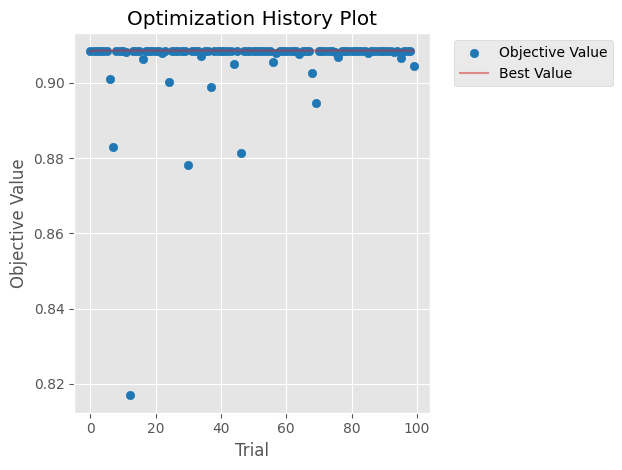

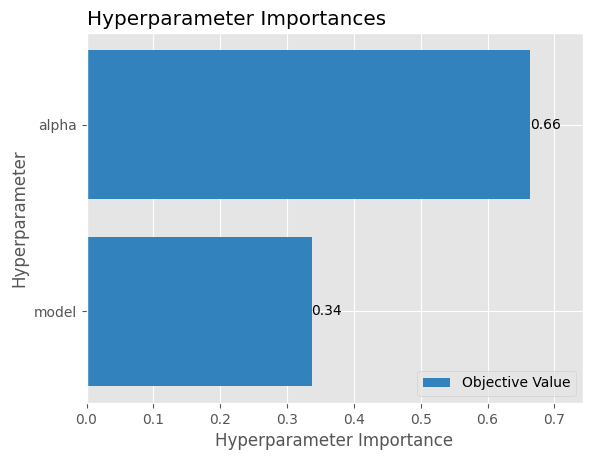

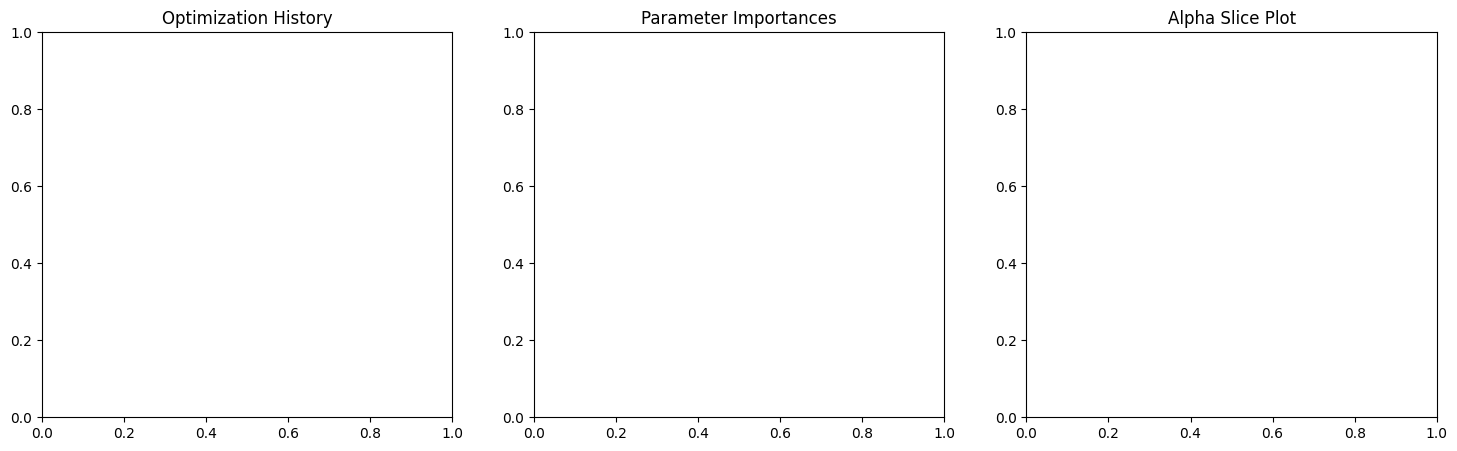

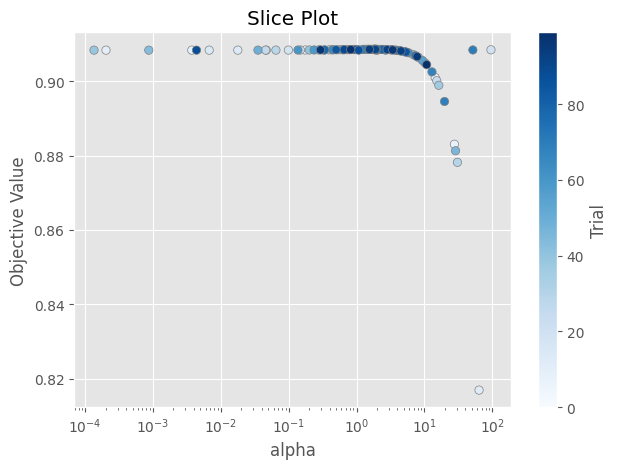

In [12]:
def multi_objective(trial):
    """Search across model types and their hyperparameters."""
    model_name = trial.suggest_categorical('model', ['Ridge', 'Lasso', 'ElasticNet'])
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)

    if model_name == 'ElasxticNet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
    elif model_name == 'Lasso':
        model = Lasso(alpha=alpha, max_iter=10000)
    else:
        model = Ridge(alpha=alpha)

    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    return scores.mean()

study_multi = optuna.create_study(direction='maximize', study_name='multi_model_tuning')
study_multi.optimize(multi_objective, n_trials=100)

print("=" * 60)
print("   MULTI-MODEL OPTUNA RESULTS (100 trials)")
print("=" * 60)
print(f"   Best R-squared:     {study_multi.best_value:.4f}")
print(f"   Best model:  {study_multi.best_params['model']}")
print(f"   Best alpha:  {study_multi.best_params['alpha']:.6f}")
if 'l1_ratio' in study_multi.best_params:
    print(f"   Best l1_ratio: {study_multi.best_params['l1_ratio']:.4f}")
print("-" * 60)

model_counts = Counter(t.params['model'] for t in study_multi.trials
                       if t.state == optuna.trial.TrialState.COMPLETE)
print("   Trials per model type:")
for model, count in model_counts.most_common():
    print(f"     {model}: {count} trials")
print("=" * 60)

from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plt.sca(axes[0])
plot_optimization_history(study_multi)
axes[0].set_title('Optimization History', fontsize=12)

plt.sca(axes[1])
plot_param_importances(study_multi)
axes[1].set_title('Parameter Importances', fontsize=12)

plt.sca(axes[2])
plot_slice(study_multi, params=['alpha'])
axes[2].set_title('Alpha Slice Plot', fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
# Split data for early stopping evaluation
X_train_es, X_test_es, y_train_es, y_test_es = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Without early stopping: train all 500 estimators
gbr_no_stop = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr_no_stop.fit(X_train_es, y_train_es)



,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [15]:
# With early stopping: stop if no improvement for 20 rounds
gbr_early_stop = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_iter_no_change=20,
    validation_fraction=0.15,
    tol=1e-4 #0.00001 --> 50 +
)
gbr_early_stop.fit(X_train_es, y_train_es)

print("=" * 60)
print("   EARLY STOPPING: GradientBoosting")
print("=" * 60)
print(f"   WITHOUT early stopping:")
print(f"     Trees built:  {gbr_no_stop.n_estimators_}")
print(f"     Test R-squared:      {gbr_no_stop.score(X_test_es, y_test_es):.4f}")
print(f"   WITH early stopping:")
print(f"     Trees built:  {gbr_early_stop.n_estimators_}")
print(f"     Test R-squared:      {gbr_early_stop.score(X_test_es, y_test_es):.4f}")
print(f"     Stopped early: {'Yes' if gbr_early_stop.n_estimators_ < 500 else 'No'}")
print(f"     Trees saved:  {500 - gbr_early_stop.n_estimators_}")
print("=" * 60)

   EARLY STOPPING: GradientBoosting
   WITHOUT early stopping:
     Trees built:  500
     Test R-squared:      0.9043
   WITH early stopping:
     Trees built:  98
     Test R-squared:      0.8807
     Stopped early: Yes
     Trees saved:  402


In [16]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train_es, y_train_es,
    eval_set=[(X_test_es, y_test_es)],
    verbose=False
)

print("=" * 60)
print("   EARLY STOPPING: XGBoost")
print("=" * 60)
print(f"   Best iteration:  {xgb_model.best_iteration}")
print(f"   Trees built:     {xgb_model.best_iteration + 1}")
print(f"   Trees saved:     {500 - xgb_model.best_iteration - 1}")
print(f"   Test R-squared:         {xgb_model.score(X_test_es, y_test_es):.4f}")
print(f"   Best RMSE:       {xgb_model.best_score:.2f}")
print("=" * 60)

   EARLY STOPPING: XGBoost
   Best iteration:  199
   Trees built:     200
   Trees saved:     300
   Test R-squared:         0.9034
   Best RMSE:       52369.68


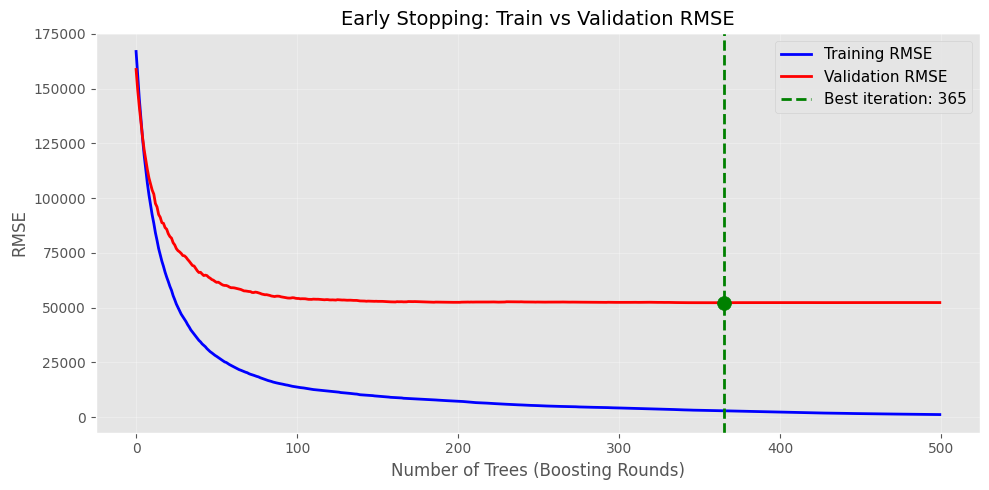


   Best iteration: 365
   Best val RMSE:  52196.79
   Final val RMSE: 52292.14
   Overfitting after iter 365: Yes


In [17]:
# Train XGBoost with eval logging for visualization
xgb_viz = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_viz.fit(
    X_train_es, y_train_es,
    eval_set=[(X_train_es, y_train_es), (X_test_es, y_test_es)],
    verbose=False
)

results = xgb_viz.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(train_rmse)), train_rmse, label='Training RMSE', color='blue', linewidth=2)
ax.plot(range(len(val_rmse)), val_rmse, label='Validation RMSE', color='red', linewidth=2)

# Mark the best iteration
best_iter = np.argmin(val_rmse)
ax.axvline(x=best_iter, color='green', linestyle='--', linewidth=2,
           label=f'Best iteration: {best_iter}')
ax.scatter([best_iter], [val_rmse[best_iter]], color='green', s=100, zorder=5)

ax.set_xlabel('Number of Trees (Boosting Rounds)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Early Stopping: Train vs Validation RMSE', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n   Best iteration: {best_iter}")
print(f"   Best val RMSE:  {val_rmse[best_iter]:.2f}")
print(f"   Final val RMSE: {val_rmse[-1]:.2f}")
print(f"   Overfitting after iter {best_iter}: "
      f"{'Yes' if val_rmse[-1] > val_rmse[best_iter] else 'No'}")